## 02 · Feature Extraction

**Goals**
1. Extract a **70-dimensional feature vector** from each audio file using `librosa`.
2. Inspect the resulting feature DataFrame (shape, missing values, dtypes).
3. Save the features as `results/audio_features.csv` for downstream models.
4. Generate **128×128 Mel-spectrogram PNG images** for use by the CNN in Notebook 05.

---
### Feature Vector Breakdown (70 features total)

| Feature group | Dim | Description |
|---|---|---|
| MFCCs mean (13) + std (13) | 26 | Captures timbral texture |
| Chroma mean (12) + std (12) | 24 | Captures harmonic / pitch content |
| Spectral centroid, bandwidth, rolloff mean+std | 6 | Brightness and energy distribution |
| Spectral contrast (7 bands) | 7 | Peak vs valley energy per sub-band |
| ZCR mean+std, RMS mean+std | 4 | Zero-crossing rate and loudness |
| Tempo, harmony, perceptr | 3 | Rhythm and psychoacoustic features |

**Expected output of this notebook:**
- Console: shape `(1000, 72)`, 0 missing values
- File: `results/audio_features.csv`
- Folder: `spectrograms_data/train/<genre>/` and `spectrograms_data/test/<genre>/` (800 + 200 PNG images)

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from src.data_loader    import find_audio_path, discover_dataset
from src.preprocessing  import extract_all_features
from src.config         import RESULTS_DIR, FEATURES_CSV, N_FEATURES, PRIMARY_COLOR

os.makedirs(RESULTS_DIR, exist_ok=True)
plt.rcParams["figure.dpi"] = 110
print("Imports OK")

Imports OK


---
## 1 · Locate Dataset

Uses `find_audio_path()` to search `data/` for the `genres_original/` folder.
**Expected:** path confirmed, 10 genres found, 1,000 total files.

In [2]:
audio_path     = find_audio_path()          # looks in data/ by default
genres, counts = discover_dataset(audio_path)

total_files = sum(counts.values())
print(f"Audio path  : {audio_path}")
print(f"Genres      : {genres}")
print(f"Total files : {total_files}")

Audio path  : /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_6_Music_Genre_Classification/data/genres_original
Genres      : ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Total files : 1000


---
## 2 · Extract Features

For each WAV file: load 30 s → compute MFCCs, chroma, spectral features → append to DataFrame.

**This step takes several minutes** (1,000 files × ~0.5 s each).
A progress bar is shown via `tqdm`. The CSV is saved automatically when complete.

**Expected output:** `DataFrame shape: (1000, 72)` — 70 features + `genre` + `filename`

In [3]:
print("Extracting features (this will take several minutes)...\n")
df = extract_all_features(audio_path, genres, save=True)

print(f"\nDataFrame shape : {df.shape}")
print(f"Expected        : ({total_files}, {N_FEATURES + 2})  [features + genre + filename]")
display(df.head(3))

Extracting features (this will take several minutes)...

  blues: 100 files
  classical: 100 files
  country: 100 files
  disco: 100 files
  hiphop: 100 files
  jazz: 100 files
  metal: 100 files
  pop: 100 files
  reggae: 100 files
  rock: 100 files

  Done — success: 999, errors: 1
  Saved: /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_6_Music_Genre_Classification/results/audio_features.csv

DataFrame shape : (999, 72)
Expected        : (1000, 72)  [features + genre + filename]


,mfcc1_mean,mfcc2_mean,mfcc3_mean,mfcc4_mean,mfcc5_mean,mfcc6_mean,mfcc7_mean,mfcc8_mean,mfcc9_mean,mfcc10_mean,...,spectral_contrast7,zcr_mean,zcr_std,rms_mean,rms_std,tempo,harmony,perceptr,genre,filename
0,-113.619385,121.553017,-19.151056,42.345768,-6.371168,18.613033,-13.692060,15.339378,-12.283618,10.973776,...,39.667577,0.083066,0.027690,0.130192,0.053201,123.046875,-0.000045,0.000007,blues,blues.00000.wav
1,-207.581512,123.997147,8.939115,35.870758,2.919970,21.518787,-8.555368,23.355938,-10.101037,11.906445,...,37.518985,0.056044,0.038059,0.095892,0.048724,67.999589,0.000142,-0.000181,blues,blues.00001.wav
2,-90.776344,140.448608,-29.100559,31.687340,-13.975971,25.741686,-13.644712,11.623112,-11.775920,9.700466,...,39.035077,0.076301,0.031738,0.175494,0.052465,161.499023,0.000001,-0.000016,blues,blues.00002.wav


---
## 3 · Data Quality Check

Verifies that all 1,000 files were processed with no missing values.
Also checks class balance: each genre should have exactly 100 rows.

**Expected output:** `None — all features extracted cleanly. ✓`

In [4]:
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0].to_string() if missing.any() else "  None — all features extracted cleanly. ✓")

print(f"\nSamples per genre:")
print(df["genre"].value_counts().to_string())

Missing values per column:
  None — all features extracted cleanly. ✓

Samples per genre:
genre
blues        100
classical    100
country      100
disco        100
hiphop       100
metal        100
pop          100
reggae       100
rock         100
jazz          99


In [5]:
feature_cols = [c for c in df.columns if c not in ("genre", "filename")]
print(f"Feature columns : {len(feature_cols)}")
display(df[feature_cols].describe().T.head(15))

Feature columns : 70


,count,mean,std,min,25%,50%,75%,max
mfcc1_mean,999.0,-144.529693,100.274374,-552.106323,-200.849762,-120.324814,-73.791950,42.112869
mfcc2_mean,999.0,99.529891,31.334739,-1.539154,76.792133,98.399033,119.732929,193.094482
mfcc3_mean,999.0,-8.930674,21.702666,-89.896149,-24.230801,-10.732934,5.539078,56.636234
mfcc4_mean,999.0,36.307606,16.668253,-18.786009,24.135523,36.979443,48.259081,80.692482
mfcc5_mean,999.0,-1.154265,12.227953,-38.915707,-9.993215,-0.045610,7.909429,31.457945
mfcc6_mean,999.0,14.644125,11.844153,-28.421492,5.086104,15.036698,23.859728,45.167530
mfcc7_mean,999.0,-5.134419,9.946546,-32.945824,-12.881134,-5.734196,2.977368,21.824984
mfcc8_mean,999.0,10.128464,10.467766,-24.940002,1.608218,9.662233,18.728802,49.023758
mfcc9_mean,999.0,-7.002739,8.287131,-31.656443,-13.268686,-7.582158,-0.379522,19.130112
mfcc10_mean,999.0,7.734505,7.941935,-12.049384,1.619162,7.148100,14.399079,27.228352


---
## 4 · Feature Value Ranges

Boxplot of MFCC mean values to illustrate why `StandardScaler` is required.
MFCC1 (overall energy) dominates other coefficients in magnitude — models that don't scale
will be biased towards MFCC1 and ignore higher-order timbral features.

**Expected output:** boxplot showing MFCC1 values ~10× larger than MFCC13

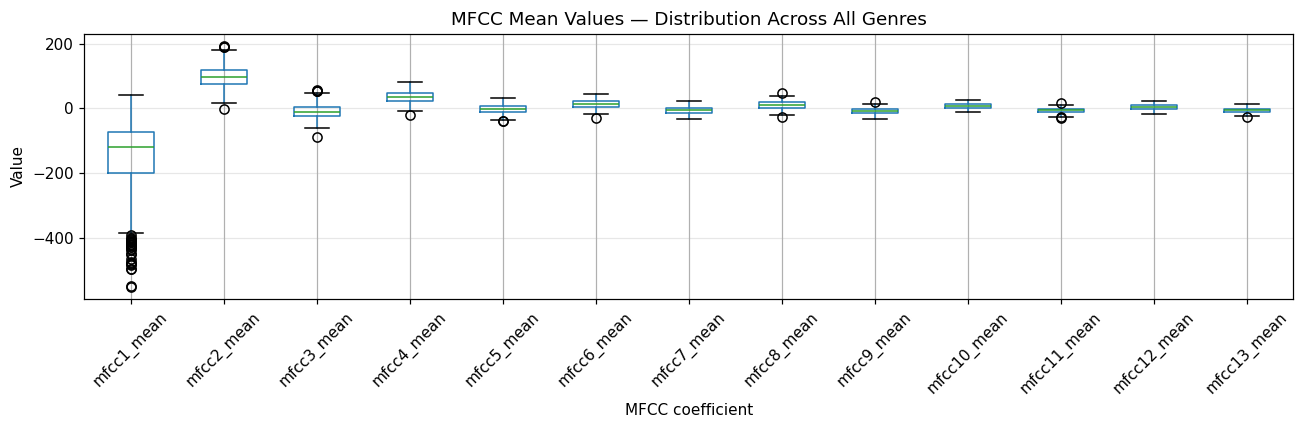


Note: MFCC values span very different ranges — StandardScaler is needed before training.


: 

In [ ]:
# MFCC mean columns — spot-check value ranges
mfcc_cols = [c for c in df.columns if "mfcc" in c and "mean" in c]

fig, ax = plt.subplots(figsize=(12, 4))
df[mfcc_cols].boxplot(ax=ax)
ax.set_title("MFCC Mean Values — Distribution Across All Genres", fontsize=12)
ax.set_xlabel("MFCC coefficient")
ax.set_ylabel("Value")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nNote: MFCC values span very different ranges — StandardScaler is needed before training.")

---
## Summary

### Extraction Result

| Metric | Value |
|---|---|
| Input files | 1,000 WAV clips |
| Features per file | 70 |
| Output shape | (1,000, 72) — 70 features + genre + filename |
| Missing values | 0 |
| Saved to | `results/audio_features.csv` |

### Why These Features?

- **MFCCs** are the gold standard for audio classification — they approximate human auditory
  perception and capture timbral texture. MFCC1 encodes overall energy; higher MFCCs encode
  finer spectral detail.
- **Chroma** captures pitch class content — useful for distinguishing harmonically rich genres
  (classical, jazz) from rhythmic ones (hiphop, reggae).
- **Spectral centroid** is the "centre of mass" of the spectrum — higher for bright/harsh sounds
  (metal), lower for warm/dark sounds (blues).
- **Tempo** encodes rhythmic pace — a strong signal for dance genres (disco, hiphop).

### Preprocessing Required

MFCC values span different ranges (e.g., MFCC1 mean ≈ –200 to +50, MFCC13 mean ≈ –5 to +5).
`StandardScaler` is applied in Notebook 04 before any tabular model is trained.

**Next**: `03_feature_analysis.ipynb` — EDA on the extracted features.